In [ ]:
# pylint: disable=unused-import
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.append('..')
from src import config
from src.data_utils import load_fraud_data, print_data_summary

print(" Environment Setup Complete")
print(f"  • Python: {sys.version.split()[0]}")
print(f"  • Pandas: {pd.__version__}")
print(f"  • NumPy: {np.__version__}")

 Environment Setup Complete
  • Python: 3.11.14
  • Pandas: 2.3.3
  • NumPy: 2.3.5


In [ ]:
# pylint: disable=undefined-variable
print("="*70)
print(" LOADING FRAUD DETECTION DATASET")
print("="*70)

data = load_fraud_data(verbose=True)
print("\n First 5 Transactions:")
display(data.head())

 LOADING FRAUD DETECTION DATASET
 Dataset loaded: 284,807 transactions
  • Features: 31 columns
  • Fraud rate: 0.1727%
  • Imbalance ratio: 578:1

 First 5 Transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("="*70)
print(" DATASET STRUCTURE ANALYSIS")
print("="*70)

print("\n1️ Basic Information:")
print(f"  • Shape: {data.shape}")
print(f"  • Rows: {data.shape[0]:,}")
print(f"  • Columns: {data.shape[1]}")
print(f"  • Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2️ Data Types:")
print(data.dtypes.value_counts())

print("\n3️ Missing Values:")
missing = data.isnull().sum()
if missing.sum() == 0:
    print("   No missing values detected - Clean dataset!")
else:
    print("   Missing values found:")
    print(missing[missing > 0])

 DATASET STRUCTURE ANALYSIS

1️ Basic Information:
  • Shape: (284807, 31)
  • Rows: 284,807
  • Columns: 31
  • Memory Usage: 67.36 MB

2️ Data Types:
float64    30
int64       1
Name: count, dtype: int64

3️ Missing Values:
   No missing values detected - Clean dataset!


 TARGET VARIABLE: CLASS DISTRIBUTION

 Class Distribution:

  Class                Count           Percentage
  Legitimate (0)       284,315         99.8273%
  Fraud (1)            492             0.1727%

 Imbalance Ratio: 578:1

 Visualization saved: assets/class_distribution.png


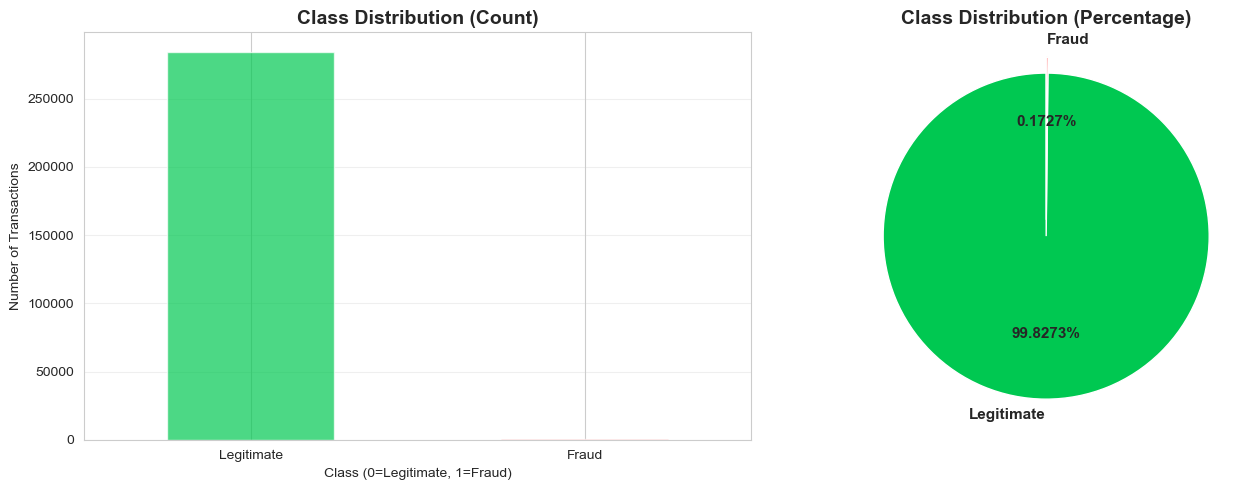

In [4]:
print("="*70)
print(" TARGET VARIABLE: CLASS DISTRIBUTION")
print("="*70)

class_counts = data['Class'].value_counts()
class_percentages = data['Class'].value_counts(normalize=True) * 100

print("\n Class Distribution:")
print(f"\n  {'Class':<20} {'Count':<15} {'Percentage'}")
print("  " + "="*50)
print(f"  {'Legitimate (0)':<20} {class_counts[0]:<15,} {class_percentages[0]:>6.4f}%")
print(f"  {'Fraud (1)':<20} {class_counts[1]:<15,} {class_percentages[1]:>6.4f}%")

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\n Imbalance Ratio: {imbalance_ratio:.0f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color=['#00C851', '#ff4444'], alpha=0.7)
axes[0].set_title('Class Distribution (Count)', fontsize=14, weight='bold')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

colors_pie = ['#00C851', '#ff4444']
explode = (0, 0.1)
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.4f%%',
            colors=colors_pie, explode=explode, startangle=90, 
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
print("\n Visualization saved: assets/class_distribution.png")
plt.show()

 TRANSACTION AMOUNT ANALYSIS

 Amount Statistics (All Transactions):
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

 Amount Statistics by Class:

Legitimate Transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

 Key Differences:
  • Legitimate median: $22.00
  • Fraud median: $9.25

 Visualization saved: assets/amount_analysis.png


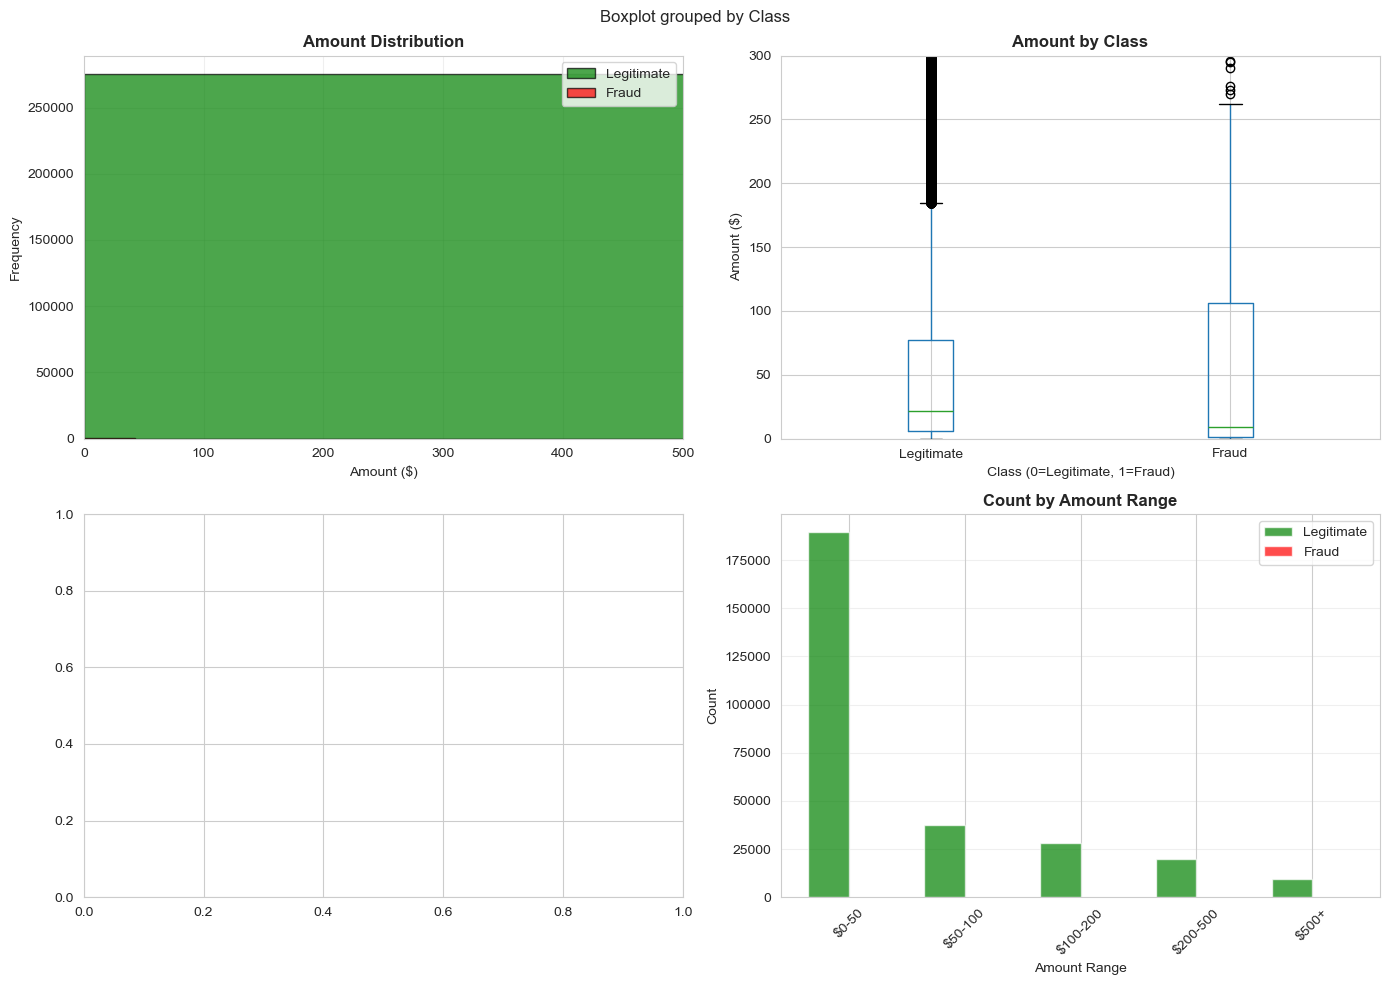

In [5]:
print("="*70)
print(" TRANSACTION AMOUNT ANALYSIS")
print("="*70)

print("\n Amount Statistics (All Transactions):")
print(data['Amount'].describe())

print("\n Amount Statistics by Class:")
print("\nLegitimate Transactions:")
print(data[data['Class']==0]['Amount'].describe())

print("\nFraudulent Transactions:")
print(data[data['Class']==1]['Amount'].describe())

legit_median = data[data['Class']==0]['Amount'].median()
fraud_median = data[data['Class']==1]['Amount'].median()

print(f"\n Key Differences:")
print(f"  • Legitimate median: ${legit_median:.2f}")
print(f"  • Fraud median: ${fraud_median:.2f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(data[data['Class']==0]['Amount'], bins=50, alpha=0.7, 
                label='Legitimate', color='green', edgecolor='black')
axes[0, 0].hist(data[data['Class']==1]['Amount'], bins=50, alpha=0.7,
                label='Fraud', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Amount Distribution', fontsize=12, weight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim([0, 500])
axes[0, 0].grid(alpha=0.3)

data.boxplot(column='Amount', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Amount by Class', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 1].set_ylabel('Amount ($)')
axes[0, 1].set_ylim([0, 300])
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Legitimate', 'Fraud'])

amount_ranges = [(0, 50), (50, 100), (100, 200), (200, 500), (500, 25000)]
range_labels = ['$0-50', '$50-100', '$100-200', '$200-500', '$500+']
legit_counts = []
fraud_counts = []

for min_amt, max_amt in amount_ranges:
    legit_counts.append(((data['Class']==0) & 
                        (data['Amount']>=min_amt) & 
                        (data['Amount']<max_amt)).sum())
    fraud_counts.append(((data['Class']==1) & 
                        (data['Amount']>=min_amt) & 
                        (data['Amount']<max_amt)).sum())

x = np.arange(len(range_labels))
width = 0.35

axes[1, 1].bar(x - width/2, legit_counts, width, label='Legitimate', color='green', alpha=0.7)
axes[1, 1].bar(x + width/2, fraud_counts, width, label='Fraud', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Amount Range')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Count by Amount Range', fontsize=12, weight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(range_labels, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/amount_analysis.png', dpi=150, bbox_inches='tight')
print("\n Visualization saved: assets/amount_analysis.png")
plt.show()


 TIME PATTERN ANALYSIS

 Time Statistics:
  • Dataset spans: 2.0 days
  • Time range: 0s to 172792s

 Fraud Distribution by Hour:
  • Peak fraud hour: Hour 19 (6 frauds)

 Visualization saved: assets/time_analysis.png


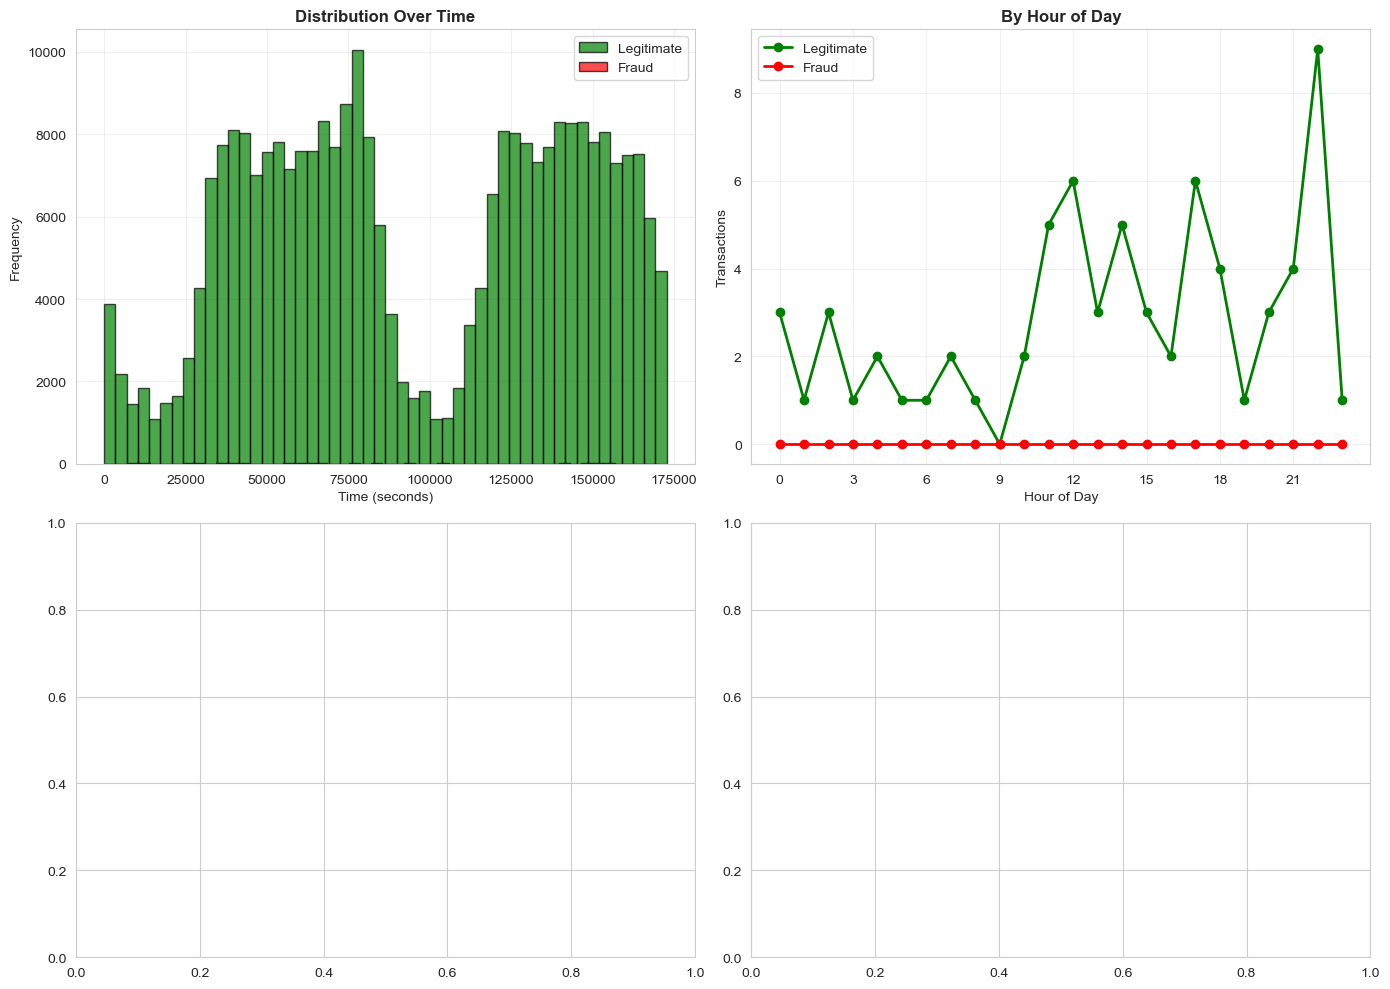

In [6]:
print("="*70)
print(" TIME PATTERN ANALYSIS")
print("="*70)

data['Hour'] = (data['Time'] / 3600) % 24
data['Day'] = (data['Time'] / 86400).astype(int)

print("\n Time Statistics:")
print(f"  • Dataset spans: {data['Time'].max() / 86400:.1f} days")
print(f"  • Time range: {data['Time'].min():.0f}s to {data['Time'].max():.0f}s")

fraud_by_hour = data[data['Class']==1].groupby('Hour').size()
legit_by_hour = data[data['Class']==0].groupby('Hour').size()

print("\n Fraud Distribution by Hour:")
print(f"  • Peak fraud hour: Hour {fraud_by_hour.idxmax():.0f} ({fraud_by_hour.max()} frauds)")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(data[data['Class']==0]['Time'], bins=50, alpha=0.7,
                label='Legitimate', color='green', edgecolor='black')
axes[0, 0].hist(data[data['Class']==1]['Time'], bins=50, alpha=0.7,
                label='Fraud', color='red', edgecolor='black')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution Over Time', fontsize=12, weight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

hours = range(24)
axes[0, 1].plot(hours, [legit_by_hour.get(h, 0) for h in hours], 
                marker='o', label='Legitimate', color='green', linewidth=2)
axes[0, 1].plot(hours, [fraud_by_hour.get(h, 0) for h in hours],
                marker='o', label='Fraud', color='red', linewidth=2)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Transactions')
axes[0, 1].set_title('By Hour of Day', fontsize=12, weight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig('../assets/time_analysis.png', dpi=150, bbox_inches='tight')
print("\n Visualization saved: assets/time_analysis.png")
plt.show()


 FEATURE CORRELATION ANALYSIS

 Top 10 Features Correlated with Fraud:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632

 Top 10 Negatively Correlated Features:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481

✓ Visualization saved: assets/feature_correlation.png


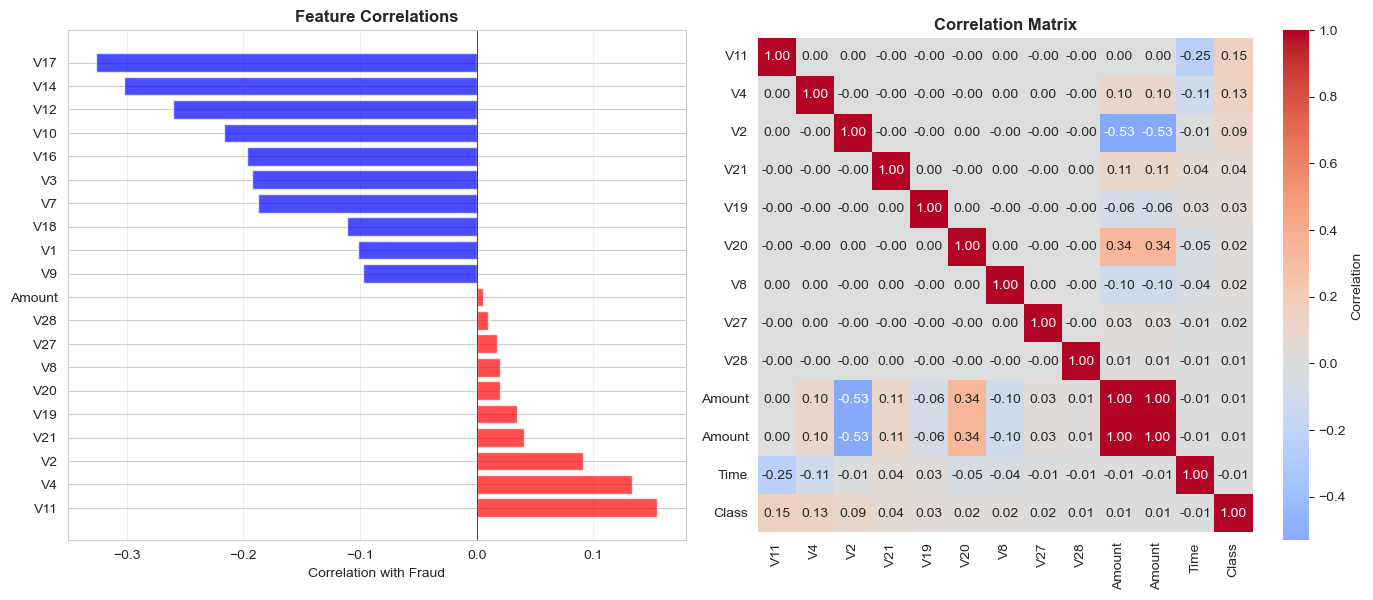

In [7]:
print("="*70)
print(" FEATURE CORRELATION ANALYSIS")
print("="*70)

correlations = data.corr()['Class'].sort_values(ascending=False)
print("\n Top 10 Features Correlated with Fraud:")
print(correlations[1:11].to_string())

print("\n Top 10 Negatively Correlated Features:")
print(correlations[-10:].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_corr = pd.concat([correlations[1:11], correlations[-10:]])
colors_corr = ['red' if x > 0 else 'blue' for x in top_corr.values]

axes[0].barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.7)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index)
axes[0].set_xlabel('Correlation with Fraud')
axes[0].set_title('Feature Correlations', fontsize=12, weight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

important_features = correlations[1:11].index.tolist() + ['Amount', 'Time', 'Class']
corr_matrix = data[important_features].corr()

import seaborn as sns
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation Matrix', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('../assets/feature_correlation.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved: assets/feature_correlation.png")
plt.show()


In [8]:
from scipy.stats import ttest_ind, chi2_contingency

print("="*70)
print(" STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

legit_amounts = data[data['Class']==0]['Amount']
fraud_amounts = data[data['Class']==1]['Amount']

t_stat, p_value = ttest_ind(legit_amounts, fraud_amounts)

print("\n1️ T-Test: Amount Difference")
print(f"  • T-statistic: {t_stat:.4f}")
print(f"  • P-value: {p_value:.6f}")
print(f"  • Result: {'Significantly different' if p_value < 0.05 else 'Not significantly different'}")



 STATISTICAL SIGNIFICANCE TESTS

1️ T-Test: Amount Difference
  • T-statistic: -3.0056
  • P-value: 0.002651
  • Result: Significantly different


In [9]:

print("="*70)
print(" BUSINESS CONTEXT & IMPLICATIONS")
print("="*70)

print("\n Key Business Findings:")

print("\n1️ Scale of the Problem")
print(f"  • Total transactions: {len(data):,}")
print(f"  • Fraud cases: {(data['Class']==1).sum()}")
print(f"  • Fraud rate: {(data['Class']==1).mean()*100:.4f}%")

print("\n2️ Financial Impact")
total_fraud_amount = data[data['Class']==1]['Amount'].sum()
avg_fraud_amount = data[data['Class']==1]['Amount'].mean()

print(f"  • Total fraud losses: ${total_fraud_amount:,.2f}")
print(f"  • Average fraud amount: ${avg_fraud_amount:,.2f}")


 BUSINESS CONTEXT & IMPLICATIONS

 Key Business Findings:

1️ Scale of the Problem
  • Total transactions: 284,807
  • Fraud cases: 492
  • Fraud rate: 0.1727%

2️ Financial Impact
  • Total fraud losses: $60,127.97
  • Average fraud amount: $122.21


In [10]:
print("="*70)
print(" DATA EXPLORATION COMPLETE")
print("="*70)

print("\n Key Discoveries:")
print("  • Extreme class imbalance (0.172% fraud)")
print("  • Fraud amounts tend to be lower")
print("  • Time patterns exist and could be predictive")
print("  • Clean dataset (no missing values)")

print("\n Next Steps:")
print("  1. Train hybrid ML+LLM model")
print("     → jupyter notebook 02_model_training.ipynb")

data = data.drop(['Hour', 'Day'], axis=1)

 DATA EXPLORATION COMPLETE

 Key Discoveries:
  • Extreme class imbalance (0.172% fraud)
  • Fraud amounts tend to be lower
  • Time patterns exist and could be predictive
  • Clean dataset (no missing values)

 Next Steps:
  1. Train hybrid ML+LLM model
     → jupyter notebook 02_model_training.ipynb
